# Práctica 9: Clasificadores

Equipo 10:
- Acevedo Medina Andrea Montserrat
- Femat Colin Viviana
- Hernández Cortez Evelin Yatziri

**Dataset:** Sleep Health & Daily Performance Dataset
https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset

Este conjunto de datos contiene 100,000 registros sintéticos de pacientes diseñados para el análisis integral de la salud del sueño, la predicción del riesgo de trastornos y el modelado del rendimiento cognitivo. Cada registro captura una instantánea diaria completa: mediciones de la arquitectura del sueño, hábitos de estilo de vida, estado psicológico y resultados cognitivos del día siguiente.

Los datos están fundamentados en la investigación: todas las distribuciones, correlaciones y perfiles específicos por ocupación están calibrados con base en fuentes revisadas por pares, incluyendo la Encuesta Nacional de Entrevistas de Salud de los CDC (2024), los estudios poblacionales de la Sleep Foundation, Frontiers in Sleep (2025) y el Framingham Heart Study. Los valores son sintéticos para garantizar la privacidad, pero las relaciones estadísticas reflejan patrones del mundo real.

[Fragmento traducido de Kaggel]

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from collections import Counter

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder, PowerTransformer, MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import BorderlineSMOTE, SMOTE


from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import precision_recall_curve, accuracy_score

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.utils import resample

from itertools import product
import functools

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# **Parte 1.** Análisis inicial

In [2]:
df = pd.read_csv("dataset_procesado.csv")
print(df.shape)
df.head()

(5000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,32318,32,Male,Driver,21.3,India,5.29,5.9,24.0,19.4,...,69.0,0.0,0.0,20.3,NaN,Winter,Weekend,72.0,Healthy,0
1,94142,18,Female,Doctor,28.6,USA,5.68,4.5,18.9,20.9,...,NaN,0.0,0.0,21.8,-0.75,Spring,Weekday,52.4,Mild,0
2,97647,27,Female,Student,28.8,NaN,6.63,4.6,24.7,19.8,...,77.0,NaN,0.0,19.5,-0.00,Summer,Weekend,63.6,Mild,0
3,68740,55,Female,Doctor,27.3,Sweden,5.50,4.5,18.6,14.7,...,72.0,NaN,0.0,19.3,1.33,Summer,Weekday,44.8,Healthy,0
4,53690,27,Female,Student,23.0,Canada,5.10,4.3,18.3,16.1,...,45.0,0.0,0.0,24.3,0.58,Spring,Weekend,61.5,Healthy,0


In [3]:
# Exploración inicial
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    5000 non-null   int64  
 1   age                          5000 non-null   int64  
 2   gender                       5000 non-null   object 
 3   occupation                   4882 non-null   object 
 4   bmi                          5000 non-null   float64
 5   country                      4512 non-null   object 
 6   sleep_duration_hrs           5000 non-null   float64
 7   sleep_quality_score          5000 non-null   float64
 8   rem_percentage               4523 non-null   float64
 9   deep_sleep_percentage        4703 non-null   float64
 10  sleep_latency_mins           4761 non-null   float64
 11  wake_episodes_per_night      4660 non-null   float64
 12  caffeine_mg_before_bed       4613 non-null   float64
 13  alcohol_units_befo

Se observa que el dataset cuenta con muchos valores nulos, esto es porque fueron imputados de manera aleatoria en vista de la falta de ellos

In [4]:
# Se analizan los valores unicos de cada columna, solo se imprimen los primeros 20

def checar_dominio_cat(df):
  """Esta función checa el dominio de las variables categóricas del dataset
  Argumentos:
    df (Dataframe): El dataframe trabajado
  Retorna:
    None (imprime el dominio de las variables categóricas)
  """
  # columnas categoricas:
  variables_cat = df.select_dtypes(include=["object"]).columns

  for col in variables_cat:
    print(f"{col}: {df[col].unique()[:20]}\n")

checar_dominio_cat(df)

gender: ['Male' 'Female' 'Other']

occupation: ['Driver' 'Doctor' 'Student' 'Homemaker' 'Nurse' 'Sales' 'Manager'
 'Software Engineer' 'Teacher' 'Freelancer' 'Retired' nan 'Lawyer']

country: ['India' 'USA' nan 'Sweden' 'Canada' 'Japan' 'Brazil' 'France' 'UK'
 'Spain' 'Germany' 'Netherlands' 'Australia' 'South Korea' 'Mexico'
 'Italy']

chronotype: ['Morning' 'Evening' 'Neutral' nan]

mental_health_condition: [nan 'Healthy' 'Anxiety' 'Depression' 'Both']

season: ['Winter' 'Spring' 'Summer' 'Autumn']

day_type: ['Weekend' 'Weekday' nan]

sleep_disorder_risk: ['Healthy' 'Mild' 'Severe' 'Moderate' nan]



In [5]:
cols_nominales = ["gender", "occupation", "country", "mental_health_condition", "season"]
cols_ordinales = ["chronotype","sleep_disorder_risk","day_type"]

Se observa que la mayoría del dominio de las variables es mayor a 4 palabras, por lo que se utilizará un label encoding, para no agregar columnas inecesarias al dataset, que ya tiene bastantes columnas.

In [6]:
# Estadísticas descriptivas
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,4523.000000,4703.000000,4761.000000,4660.000000,4613.000000,...,4646.000000,5000.000000,4577.000000,4694.000000,4674.000000,4850.000000,5000.000000,4764.000000,5000.000000,5000.000000
mean,49745.522000,34.7392,26.349060,6.411310,4.873980,20.213663,20.258197,19.955472,3.357082,39.460221,...,15.243866,5.707340,7.214245,66.583298,0.563971,0.081443,20.563340,1.197676,59.046820,0.380000
std,28874.696158,11.1777,4.491987,1.259138,1.484515,3.413186,4.329297,7.611890,1.922507,70.248839,...,21.370869,1.598144,3.398855,7.281367,0.495944,0.273543,2.939628,0.795740,22.152913,0.485435
min,17.000000,18.0000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.000000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,24140.750000,26.0000,23.200000,5.520000,3.800000,18.000000,17.350000,15.000000,2.000000,0.000000,...,0.000000,4.800000,4.900000,62.000000,0.000000,0.000000,18.500000,0.650000,44.300000,0.000000
50%,49957.500000,33.0000,26.300000,6.360000,4.900000,20.300000,20.300000,20.000000,3.000000,0.000000,...,0.000000,5.800000,7.500000,66.000000,1.000000,0.000000,20.500000,1.190000,60.150000,0.000000
75%,74304.000000,43.0000,29.400000,7.250000,6.000000,22.600000,23.300000,25.000000,5.000000,80.000000,...,31.000000,6.800000,9.700000,71.000000,1.000000,0.000000,22.600000,1.750000,75.400000,1.000000
max,99980.000000,69.0000,42.700000,10.500000,9.200000,30.000000,30.000000,47.000000,8.000000,400.000000,...,105.000000,10.000000,18.000000,92.000000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


No se observa ningún comportamiento extraño en las estadísticas descriptivas, como algún valores mínimos o máximos falsos que se puedan identificar a simple vista.

In [7]:
# Conteo de nulos
df.isnull().sum()

,0
person_id,0
age,0
gender,0
occupation,118
bmi,0
country,488
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,477
deep_sleep_percentage,297


In [8]:
# Conteo de duplicados
df.duplicated().sum()

np.int64(0)

Se buscaron valores duplicados para evitar data leakage, pero no se encontró ninguno

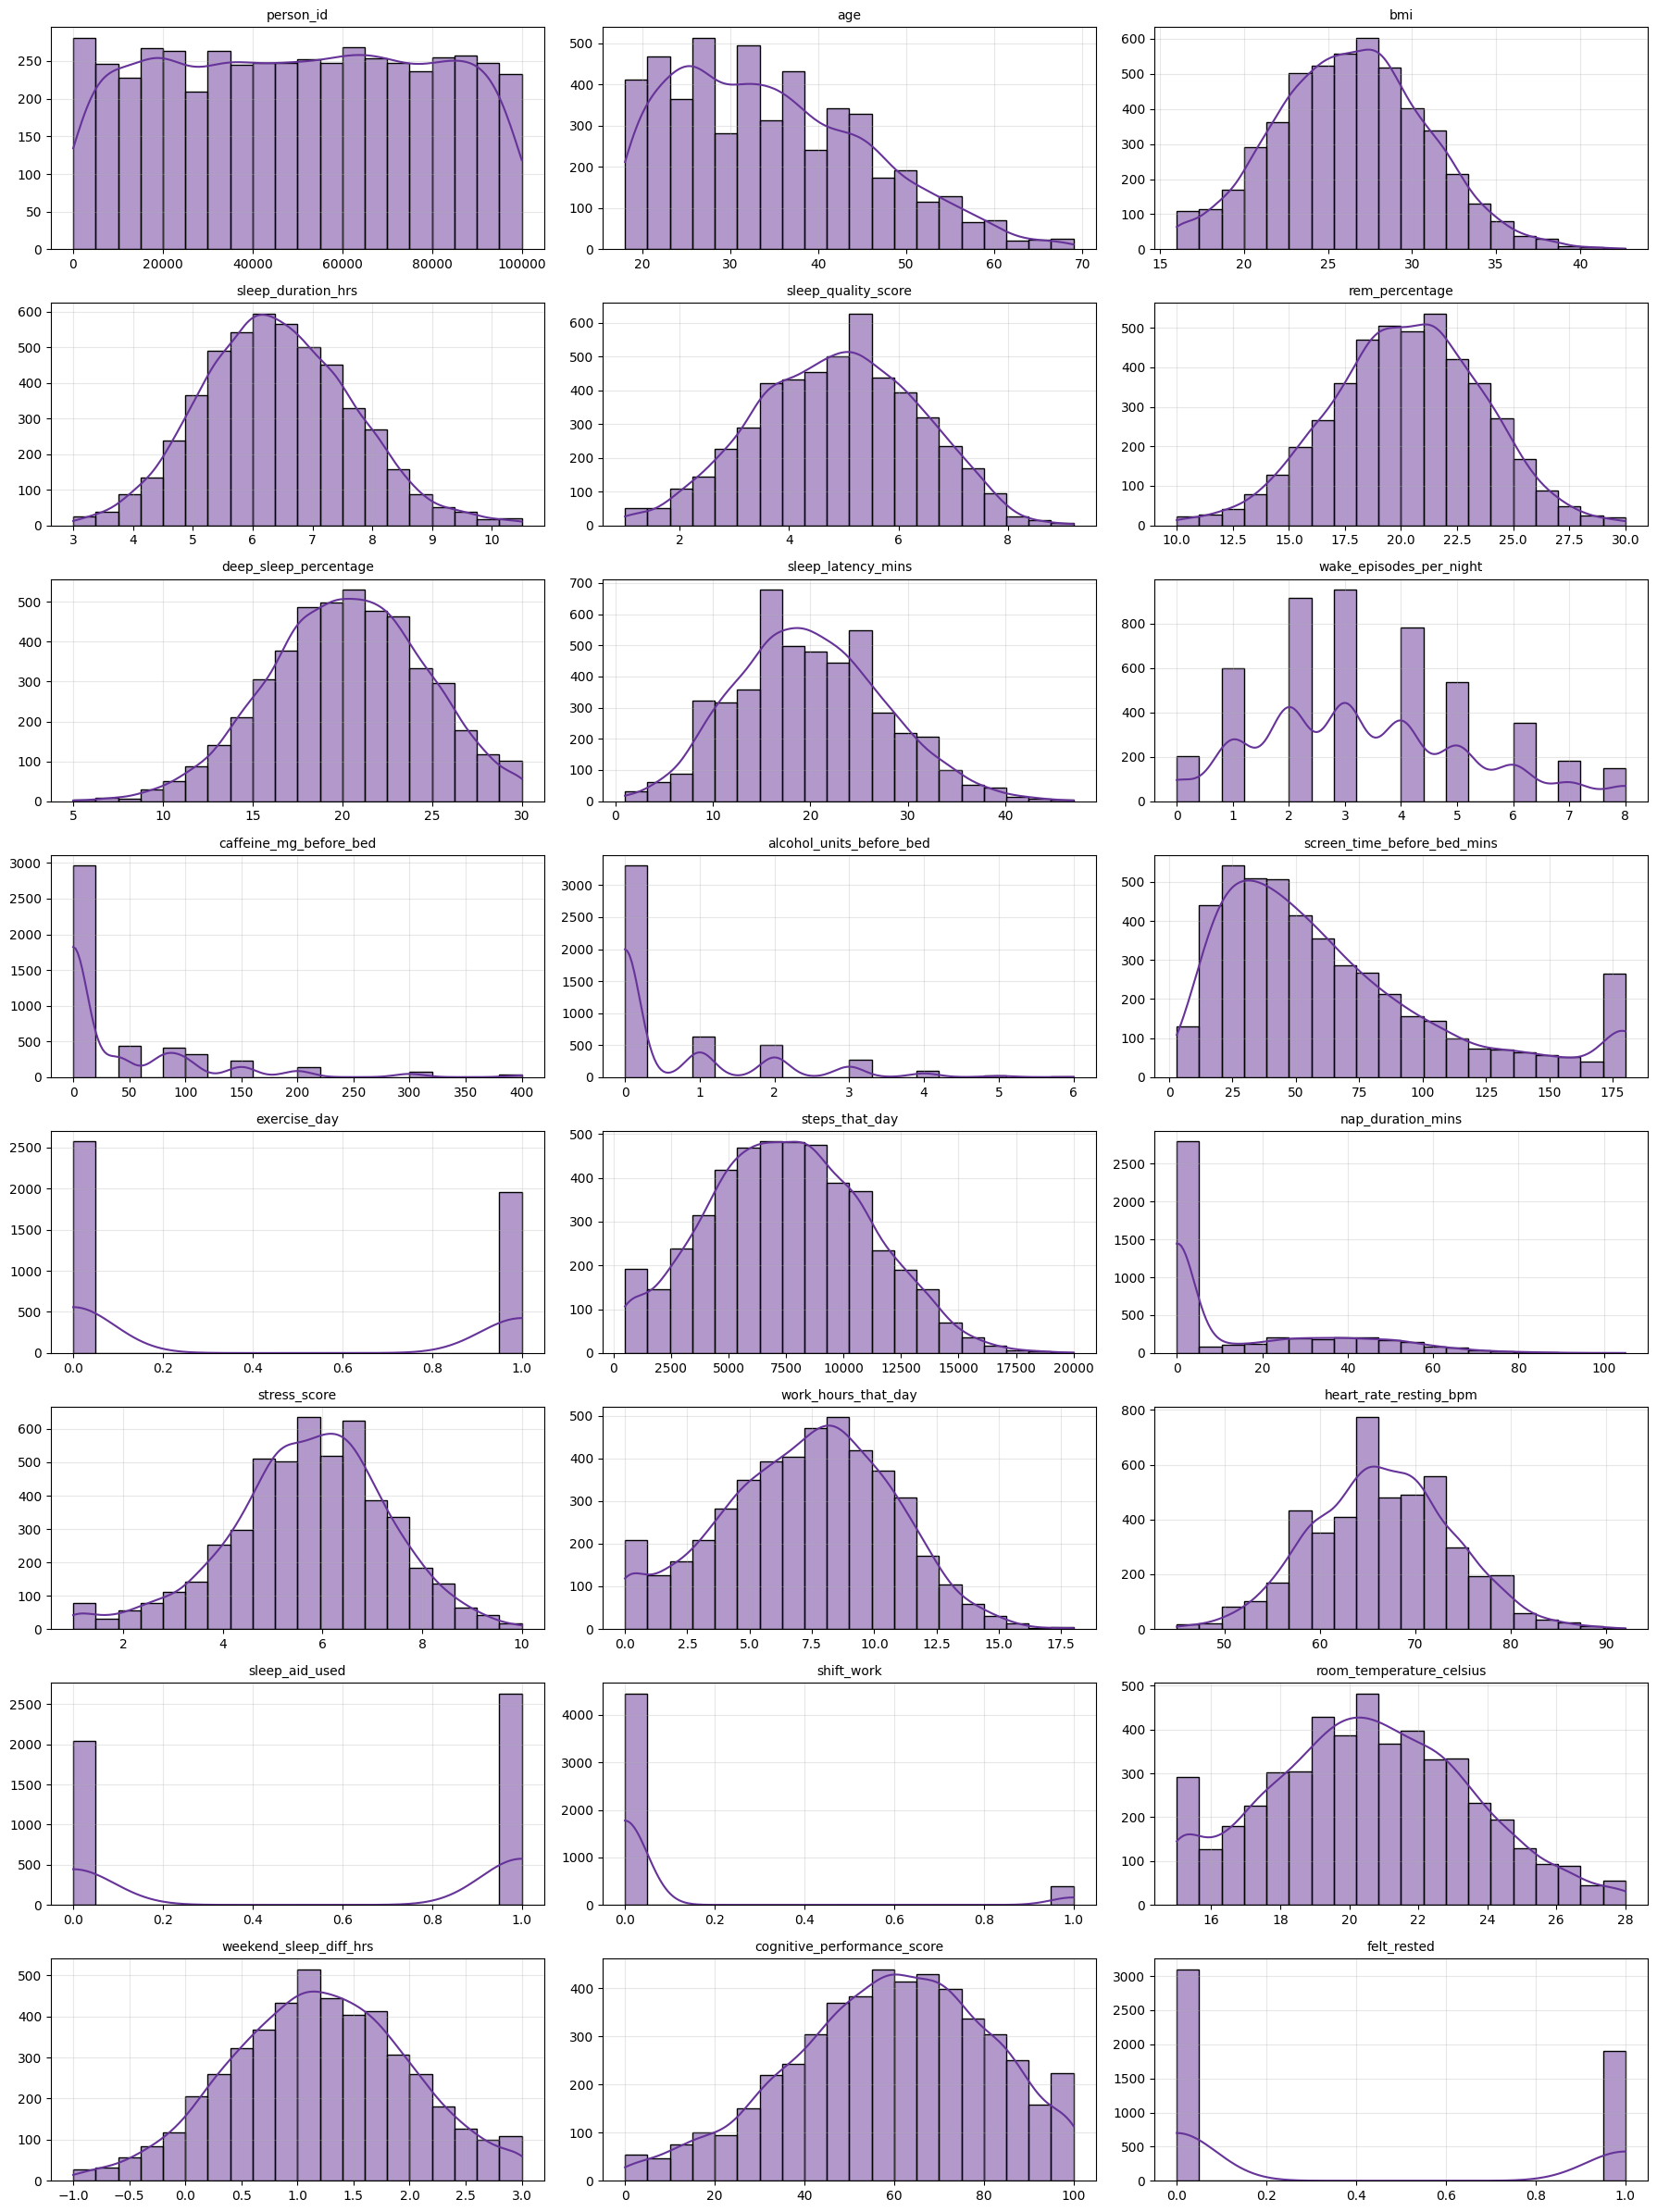

In [9]:
# Observar distribuciones

def analis_distribucion_hist(df, n_cols = 3):
  """
  Función que muestra diagramas de caja por cada variable
  Argumentos:
    df (dataframe): Dataframe con los datos
    n_cols (int): Número de columnas para el grid
  Retorna:
    None (muestra diagramas)
  """
  # variables numericas
  variables_numericas = df.select_dtypes(include=[np.number]).columns
  n_rows = len(variables_numericas) // 3

  fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
  axes = axes.flatten()

  for i, col in enumerate(variables_numericas):
      sns.histplot(
          df[col],
          bins=20,
          kde=True,
          ax=axes[i],
          color="rebeccapurple",
          alpha=0.5
      )

      axes[i].set_title(col, fontsize=10)
      axes[i].set_xlabel("")
      axes[i].set_ylabel("")
      axes[i].grid(alpha=0.3)

  #plt.suptitle("Distribuciones de las variables numéricas ", fontsize=14)
  plt.tight_layout()
  plt.show()

analis_distribucion_hist(df)

Se guardarán las columnas que no aparentan una distribución gaussiana, ya que este es un supuesto para el clasificador NBGaussian

In [10]:
cols_no_gaussianas =["age","alcohol_units_before_bed","alcohol_units_before_bed","nap_duration_mins","sleep_aid_used","shift_work"]

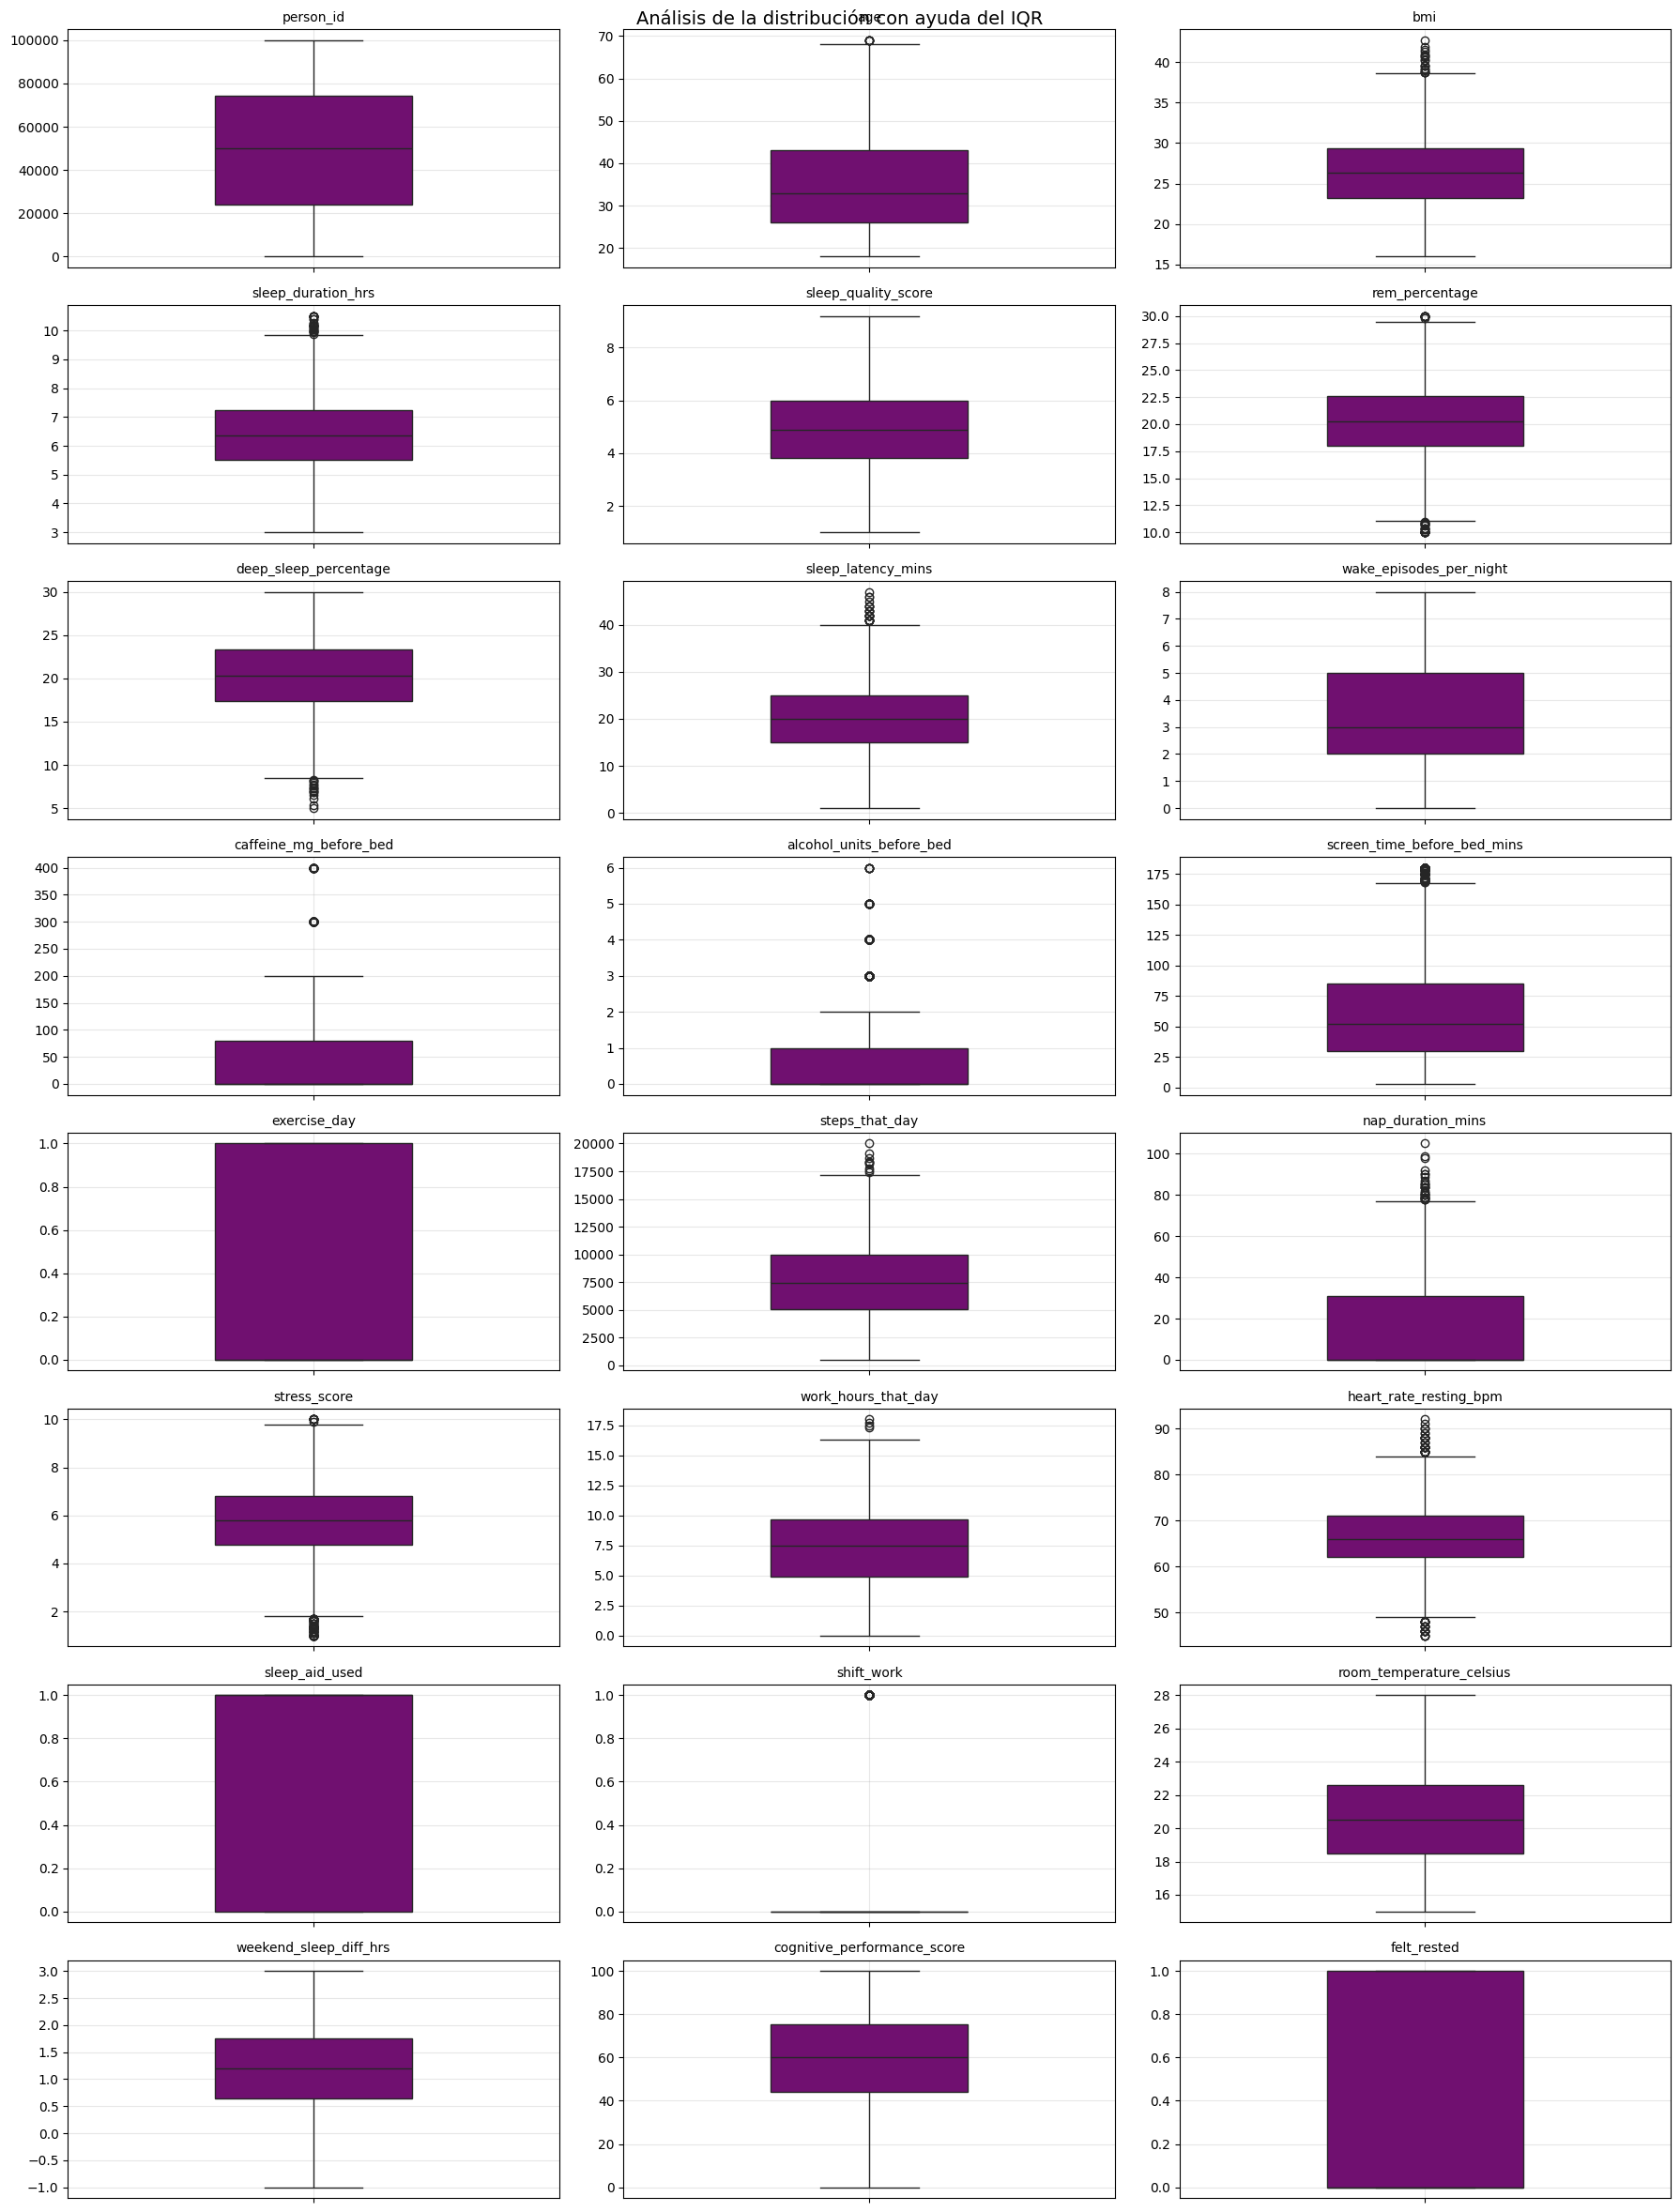

In [11]:

def analis_distribucion_boxplot(df, n_cols = 3):
  """
  Función que muestra diagramas de caja por cada variable
  Argumentos:
    df (dataframe): Dataframe con los datos
    variables_numericas (lista): Lista de variables numéricas del df
    n_cols (int): Número de columnas para el grid
  Retorna:
    None (muestra diagramas)
  """
  variables_numericas = df.select_dtypes(include=[np.number]).columns
  n_rows = len(variables_numericas) // 3


  fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
  axes = axes.flatten()

  for i, col in enumerate(variables_numericas):
      sns.boxplot(
          y=df[col],
          ax=axes[i],
          color="purple",
          width=0.4)

      axes[i].set_title(col, fontsize=10)
      axes[i].set_xlabel("")
      axes[i].set_ylabel("")
      axes[i].grid(alpha=0.3)

  plt.suptitle("Análisis de la distribución con ayuda del IQR", fontsize=14)
  plt.tight_layout()
  plt.show()

analis_distribucion_boxplot(df)

Con ayuda del IQR se identificó que no hay una cantidad significatica de outliers en el dataframe, por lo que se tratarán con una winzorización ligera, o no se tratarán en absoluto, dependiendo del modelo.

In [12]:
def correlacion(df):
  """
  Función que muestra una matriz de correlación para las variables numéricas por medio de un mapa de calor.
  Argumentos:
    df (DataFrame): dataFrame con los datos.
  Retorna:
    None. Muestra un heatmap con las correlaciones.
  """

  plt.figure(figsize=(10,8))
  sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm")
  plt.title(f"Matriz de correlación")
  plt.show()

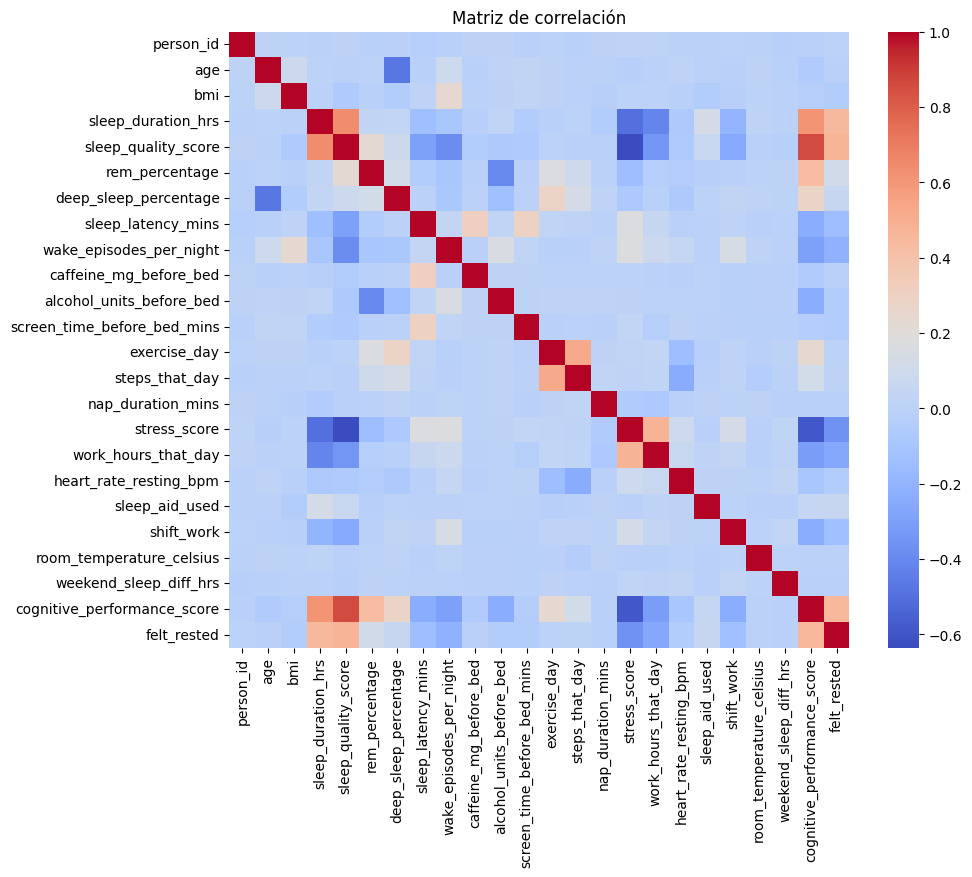

In [13]:
correlacion(df)

Si bien existe un gran número de variables, no muestran una multicorrelación, lo que será de utilidad en el modelo de Regresión Lineal al cual le afectaría esto.

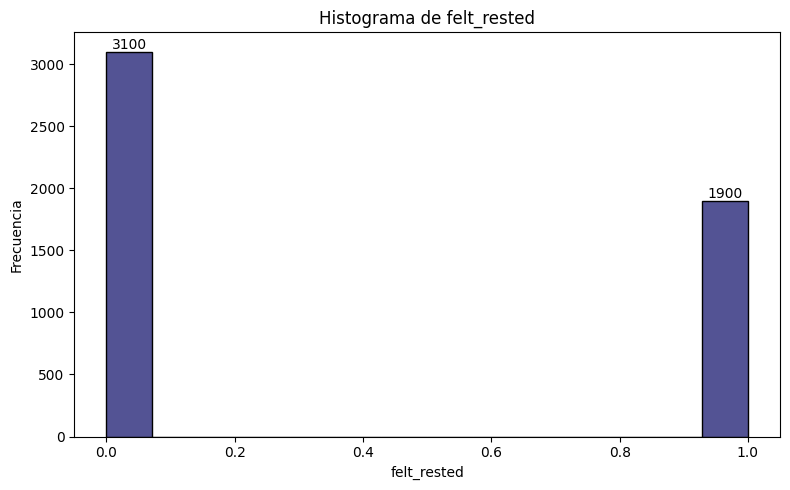

In [14]:

def histograma_con_conteo(df, columna_objetivo):
  """
  Genera un histograma con conteo encima de cada barra
  Argumentos:
    df (DataFrame): dataset
    columna_objetivo (str): nombre de la columna a graficar
  Retorna:
    None. Muestra el histograma con conteo encima de cada barra
  """
  plt.figure(figsize=(8,5))

  ax = sns.histplot(data=df, x=columna_objetivo, color = "midnightblue")

  for barra in ax.patches:
    altura = barra.get_height()
    if altura > 0:
      ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        int(altura),
        ha='center',
        va='bottom'
    )

  plt.title(f"Histograma de {columna_objetivo}")
  plt.xlabel(columna_objetivo)
  plt.ylabel("Frecuencia")
  plt.tight_layout()
  plt.show()

histograma_con_conteo(df, "felt_rested")

Se identifica un desbalance con un IR de 1.6. Por ello, se aplicará un random undersampling solamente del 15%, para no eliminar registros significativos, y un SMOTE

Antes de arreglar el desbalance, se realizará el preprocesamiento necesario.

In [15]:
# eliminar la columna person_id en el dataset
df = df.drop(columns=["person_id"])

# **Parte 2.** Preprocesamiento para cada modelo

Se tienen 4 pipelines para el tratamiento apropiado de los distintos clasificadores. Así mismo, se debe de realizar un balanceo de datos a cada dataset obtenido, para ello se deben de dividir en conjunto de entrenamiento y conjunto de prueba

In [16]:
def balancear_dataset(X, y, clases_undersample,porcentaje_reduccion=0.2,porcentaje_incremento=0.2):

  """
  Balancea un dataset aplicando undersampling y BorderlineSMOTE
  Argumentos:
    X (DataFrame): Dataset sin la columna de clase
    y (Series): Columna de clase
    clases_undersample (list): Lista de clases a las que se le aplicará undersampling
    porcentaje_reduccion (float): El porcentaje que se le reducirá a las clases mayoritarias
    max_incremento (float): El máximo porcentaje que se le aumentará a las clases minoritarias
  Retorna:
    X_final (DataFrame): Dataset balanceado
    y_final (Series): Columna de clase balanceada
  """

  # Undersampling
  conteo = Counter(y) # Diccionario de {clase : conteo}
  estrategia_under = {}

  print("Distribución original:")
  print(conteo, "\n")

  for clase, cantidad in conteo.items():
    # Reducir las clases seleccionadas
    if clase in clases_undersample:
      nueva_cantidad = int(cantidad * (1 - porcentaje_reduccion))
      estrategia_under[clase] = nueva_cantidad
    else:
      estrategia_under[clase] = cantidad

  rus = RandomUnderSampler(sampling_strategy=estrategia_under,random_state=42)
  X_res, y_res = rus.fit_resample(X, y)


  # Oversampling

  conteo = Counter(y_res)
  estrategia_over = {}
  max_clase = max(conteo.values())

  print("Después de undersampling:")
  print(conteo, "\n")

  for clase, cantidad in conteo.items():
    if cantidad < max_clase:
      incremento_max = int(cantidad * (1 + porcentaje_incremento))
      estrategia_over[clase] = min(incremento_max, max_clase)

  smote = BorderlineSMOTE(sampling_strategy=estrategia_over,random_state=42,k_neighbors=5)

  X_final, y_final = smote.fit_resample(X_res, y_res)

  print("Después de oversampling:")
  print(Counter(y_final))

  return X_final, y_final

In [17]:
# Las columnas se deben de procesar de manera diferente según el modelo que se esté aplicando

cols_nominales = ["gender", "occupation", "country", "mental_health_condition", "season"]
cols_ordinales = ["chronotype", "sleep_disorder_risk", "day_type"]


cols_numericas = [
  "age", "bmi", "sleep_duration_hrs", "sleep_quality_score", "rem_percentage",
  "deep_sleep_percentage", "sleep_latency_mins", "wake_episodes_per_night",
  "caffeine_mg_before_bed", "alcohol_units_before_bed", "screen_time_before_bed_mins",
  "exercise_day", "steps_that_day", "nap_duration_mins", "stress_score",
  "work_hours_that_day", "heart_rate_resting_bpm", "sleep_aid_used", "shift_work",
  "room_temperature_celsius", "weekend_sleep_diff_hrs", "cognitive_performance_score"
]

col_objetivo = 'felt_rested'


In [18]:
# Separación con dataset original para aplicar pipeline y balanceo posteriormente
X = df.drop(columns=[col_objetivo])
y = df[col_objetivo]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


###**Dataset A:** Familia de árboles

In [19]:

def preprocesar_datos_arboles(df, cols_nominales, cols_ordinales, cols_numericas):
  """
  Aplica imputación, codificación y escalado mediante un Pipeline para modelos de árboles

  Argumentos:
    df (DataFrame): dataset original que se desea preprocesar.
    cols_nominales (list): lista con los nombres de las columnas categóricas nominales
    cols_ordinales (list): lista con los nombres de las columnas categóricas ordinales
    cols_numericas (list): lista con los nombres de las columnas numéricas
  Retorna:
    df_procesado (DataFrame): dataset transformado, con nulos imputados, categorías codificadas y valores escalados.
    preprocessor (ColumnTransformer): el pipeline ajustado, listo para usarse en nuevos datos de prueba.
  """

  # Pipeline variables numéricas
  pipeline_num = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    #('scaler', StandardScaler())
  ])

  # Pipeline variables categóricas
  pipeline_cat = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
  ])

  # Ensamblar todo en un ColumnTransformer
  preprocessor = ColumnTransformer(transformers=[
    ('num', pipeline_num, cols_numericas),
    ('cat_nom', pipeline_cat, cols_nominales),
    ('cat_ord', pipeline_cat, cols_ordinales)
  ], remainder='passthrough')

  # Ajustar y transformar los datos
  datos_transformados = preprocessor.fit_transform(df)

  # Reconstruir el DataFrame para no perder los nombres de las columnas
  cols_salida = cols_numericas + cols_nominales + cols_ordinales
  cols_restantes = [col for col in df.columns if col not in cols_salida]
  cols_finales = cols_salida + cols_restantes

  df_procesado = pd.DataFrame(datos_transformados, columns=cols_finales, index=df.index)

  return df_procesado, preprocessor



df_arboles, pipeline_arboles = preprocesar_datos_arboles(df, cols_nominales, cols_ordinales, cols_numericas)

df_arboles.head()

,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,...,cognitive_performance_score,gender,occupation,country,mental_health_condition,season,chronotype,sleep_disorder_risk,day_type,felt_rested
0,32.0,21.3,5.29,5.9,24.0,19.4,5.0,3.0,0.0,1.0,...,72.0,1.0,1.0,5.0,3.0,3.0,1.0,0.0,1.0,0.0
1,18.0,28.6,5.68,4.5,18.9,20.9,15.0,5.0,0.0,0.0,...,52.4,0.0,0.0,14.0,3.0,1.0,0.0,1.0,0.0,0.0
2,27.0,28.8,6.63,4.6,24.7,19.8,34.0,4.0,0.0,0.0,...,63.6,0.0,10.0,14.0,0.0,2.0,0.0,1.0,1.0,0.0
3,55.0,27.3,5.50,4.5,18.6,14.7,12.0,2.0,0.0,1.0,...,44.8,0.0,0.0,12.0,3.0,2.0,2.0,0.0,0.0,0.0
4,27.0,23.0,5.10,4.3,18.3,16.1,20.0,2.0,0.0,0.0,...,61.5,0.0,10.0,2.0,3.0,1.0,2.0,0.0,1.0,0.0


Este dataset tuvo:
- Imputación simple, ya que son modelos robustos
- No tratamiento de outliers, ya que los árboles son robustos ante ellos, mandándolos todos al mismo nodo
- Se utilizó un OrdinalEncoder a todas las variables numéricas, porque los árboles no asumen linealidad
- Los árboles no necesitan un escalado estrictamente, pero se agregó uno para las columnas numéricas


In [20]:
# Se aplica el pipeline al dataset original
X_train_arboles = pipeline_arboles.fit_transform(X_train)

# Se trata el desbalance
X_train_arboles, y_train_arboles = balancear_dataset(X_train_arboles, y_train,[0])

X_test_arboles = pipeline_arboles.transform(X_test)

Distribución original:
Counter({0: 2480, 1: 1520}) 

Después de undersampling:
Counter({0: 1984, 1: 1520}) 

Después de oversampling:
Counter({0: 1984, 1: 1824})


###**Dataset B:** Familia de Distancia y Lineales (KNN, Regresión Logística, SVM)

In [21]:

# Transformador personalizado para tratar outliers dentro del Pipeline
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Limita los valores extremos (outliers) de un dataset a los percentiles especificados.
  """
  def __init__(self, limite_inferior=0.05, limite_superior=0.95):
    self.limite_inferior = limite_inferior
    self.limite_superior = limite_superior

  def fit(self, X, y=None):
    X = pd.DataFrame(X)
    self.lower_bounds_ = X.quantile(self.limite_inferior)
    self.upper_bounds_ = X.quantile(self.limite_superior)
    return self

  def transform(self, X, y=None):
    X_copia = pd.DataFrame(X).copy()
    for col in X_copia.columns:
      X_copia[col] = np.clip(X_copia[col], self.lower_bounds_[col], self.upper_bounds_[col])
    return X_copia


def preprocesar_datos_distancia(df, cols_nominales, cols_ordinales, cols_numericas):
    """
    Aplica imputación, winsorización, codificación (OHE y Ordinal) y escalado para modelos de distancia

    Argumentos:
      df (DataFrame): dataset original que se desea preprocesar
      cols_nominales (list): lista con los nombres de las columnas categóricas nominales
      cols_ordinales (list): lista con los nombres de las columnas categóricas ordinales
      cols_numericas (list): lista con los nombres de las columnas numéricas

    Retorna:
      df_procesado (DataFrame): dataset transformado, con nulos imputados, categorías codificadas, winsorizado y escalado
      preprocessor (ColumnTransformer): el pipeline ajustado, listo para usarse en nuevos datos
    """

    # Pipeline numérico
    pipeline_num = Pipeline(steps=[
      ('imputer', KNNImputer(n_neighbors=5)), # Mejor para modelos de distancia
      ('winsorizer', Winsorizer(limite_inferior=0.05, limite_superior=0.95)),
      ('scaler', StandardScaler())
    ])

    # Pipeline categórico nominal
    pipeline_cat_nom = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # Pipeline categórico ordinal
    orden_chronotype = ['Morning', 'Neutral', 'Evening']
    orden_dia = ['Weekday', 'Weekend']
    orden_riesgo = ['Healthy', 'Mild', 'Moderate', 'Severe']

    pipeline_cat_ord = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('ordinal', OrdinalEncoder(categories=[orden_chronotype, orden_dia, orden_riesgo], handle_unknown='use_encoded_value', unknown_value=-1))
    ])

    # Ensamblar todo en un ColumnTransformer
    preprocessor = ColumnTransformer(transformers=[
      ('num', pipeline_num, cols_numericas),
      ('cat_nom', pipeline_cat_nom, cols_nominales),
      ('cat_ord', pipeline_cat_ord, cols_ordinales)
    ], remainder='passthrough')

    # Ajustar y transformar los datos
    datos_transformados = preprocessor.fit_transform(df)

    # Reconstruir el DataFrame (obtener nombres de columnas del OneHot)
    nombres_ohe = preprocessor.named_transformers_['cat_nom']['ohe'].get_feature_names_out(cols_nominales)

    cols_salida = cols_numericas + list(nombres_ohe) + cols_ordinales
    cols_restantes = [col for col in df.columns if col not in (cols_numericas + cols_nominales + cols_ordinales)]
    cols_finales = cols_salida + cols_restantes

    df_procesado = pd.DataFrame(datos_transformados, columns=cols_finales, index=df.index)

    return df_procesado, preprocessor


df_distancias, pipeline_distancias = preprocesar_datos_distancia(df, cols_nominales, cols_ordinales, cols_numericas)
df_distancias.head()

,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,...,mental_health_condition_Depression,mental_health_condition_Healthy,season_Autumn,season_Spring,season_Summer,season_Winter,chronotype,sleep_disorder_risk,day_type,felt_rested
0,-0.237795,-1.217496,-0.973347,0.733467,1.271425,-0.230451,-1.714044,-0.207904,-0.669742,0.428819,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-1.0,-1.0,0.0
1,-1.466268,0.551233,-0.632210,-0.274557,-0.446794,0.155412,-0.701611,0.942643,-0.669742,-0.610490,...,0.0,1.0,0.0,1.0,0.0,0.0,2.0,-1.0,-1.0,0.0
2,-0.710285,0.599691,0.198764,-0.202555,1.507259,-0.127554,1.901790,0.367369,-0.669742,-0.610490,...,0.0,0.0,0.0,0.0,1.0,0.0,2.0,-1.0,-1.0,0.0
3,1.935659,0.236254,-0.789658,-0.274557,-0.547865,-1.439490,-1.135511,-0.783177,0.291691,0.428819,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,-1.0,-1.0,0.0
4,-0.710285,-0.805601,-1.139542,-0.418561,-0.648937,-1.079351,0.021556,-0.783177,-0.669742,-0.610490,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-1.0,-1.0,0.0


Para este conjunto de modelos:
- Se escaló adecuadamente con un StandardScales, ya que trabajan con distancias, y en específico el KNN trabaja mejor con la distancia euclidiana.
- Se diferenciaron las columnas categóricas ordinales de las nominales, para aplicar un tipo distinto de encoder, y no introducir falsa ordinalidad a los modelos, y al mismo tiempo evitar utilizar OneHot para todas las variables, ya que el dataset tiene bastantes columnas
- Se winzorizó, ya que son sensibles a outliers
- Se realizó una imputación más robusta, ya que estos modelos no son tan robustos ante esta problemática

In [22]:
# Se aplica el pipeline al dataset original
X_train_distancias = pipeline_distancias.fit_transform(X_train)

# Se trata el desbalance
X_train_distancias, y_train_distancias = balancear_dataset(X_train_distancias, y_train,[0])

X_test_distancias = pipeline_distancias.transform(X_test)

Distribución original:
Counter({0: 2480, 1: 1520}) 

Después de undersampling:
Counter({0: 1984, 1: 1520}) 

Después de oversampling:
Counter({0: 1984, 1: 1824})


###**Dataset C:** Familia de Naive Bayes

In [23]:
# Para no modificar las distribuciones gaussianas
class Winsorizer(BaseEstimator, TransformerMixin):
    """
    Limita los valores extremos (outliers) de un dataset a los percentiles especificados.
    """
    def __init__(self, limite_inferior=0.01, limite_superior=0.99):
        self.limite_inferior = limite_inferior
        self.limite_superior = limite_superior

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.lower_bounds_ = X.quantile(self.limite_inferior)
        self.upper_bounds_ = X.quantile(self.limite_superior)
        return self

    def transform(self, X, y=None):
        X_copia = pd.DataFrame(X).copy()
        for col in X_copia.columns:
            X_copia[col] = np.clip(X_copia[col], self.lower_bounds_[col], self.upper_bounds_[col])
        return X_copia

# 2. Función Principal
def preprocesar_datos_naive_bayes(df, cols_nominales, cols_ordinales, cols_numericas):
    """
    Aplica imputación, winsorización ligera, transformación de Yeo-Johnson (Gaussiana) y codificación categórica

    Argumentos:
      df (DataFrame): dataset original que se desea preprocesar
      cols_nominales (list): lista con los nombres de las columnas categóricas nominales
      cols_ordinales (list): lista con los nombres de las columnas categóricas ordinales
      cols_numericas (list): lista con los nombres de las columnas numéricas
    Retorna:
      df_procesado (DataFrame): dataset transformado, optimizado para distribuciones gaussianas
      preprocessor (ColumnTransformer): el pipeline ajustado
    """

    # Pipeline numérico
    pipeline_num = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='median')),
      ('winsorizer', Winsorizer(limite_inferior=0.01, limite_superior=0.99)),
      ('yeo_johnson', PowerTransformer(method='yeo-johnson', standardize=True)) # Estanzariza a media = 0 y varianza = 1
    ])

    # Pipeline categórico nominal
    pipeline_cat_nom = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # Pipeline categórico ordinal
    orden_chronotype = ['Morning', 'Neutral', 'Evening']
    orden_dia = ['Weekday', 'Weekend']
    orden_riesgo = ['Healthy', 'Mild', 'Moderate', 'Severe']

    pipeline_cat_ord = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('ordinal', OrdinalEncoder(categories=[orden_chronotype, orden_dia, orden_riesgo], handle_unknown='use_encoded_value', unknown_value=-1))
    ])


    # Ensamblar todo en un ColumnTransformer
    preprocessor = ColumnTransformer(transformers=[
      ('num', pipeline_num, cols_numericas),
      ('cat_nom', pipeline_cat_nom, cols_nominales),
      ('cat_ord', pipeline_cat_ord, cols_ordinales)
    ], remainder='passthrough')

    # Ajustar y transformar los datos
    datos_transformados = preprocessor.fit_transform(df)

    # Reconstruir el DataFrame (obtener nombres de columnas del OneHot)
    nombres_ohe = preprocessor.named_transformers_['cat_nom']['ohe'].get_feature_names_out(cols_nominales)

    cols_salida = cols_numericas + list(nombres_ohe) + cols_ordinales
    cols_restantes = [col for col in df.columns if col not in (cols_numericas + cols_nominales + cols_ordinales)]
    cols_finales = cols_salida + cols_restantes

    df_procesado = pd.DataFrame(datos_transformados, columns=cols_finales, index=df.index)

    return df_procesado, preprocessor


df_nb, pipeline_nb = preprocesar_datos_naive_bayes(df, cols_nominales, cols_ordinales, cols_numericas)
df_nb.head()

,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,...,mental_health_condition_Depression,mental_health_condition_Healthy,season_Autumn,season_Spring,season_Summer,season_Winter,chronotype,sleep_disorder_risk,day_type,felt_rested
0,-0.100532,-1.133491,-0.895981,0.697980,1.197937,-0.220803,-2.259885,-0.075627,-0.700467,1.295309,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-1.0,-1.0,0.0
1,-1.869377,0.516151,-0.564097,-0.261788,-0.433741,0.141091,-0.642145,0.918458,-0.700467,-0.667480,...,0.0,1.0,0.0,1.0,0.0,0.0,2.0,-1.0,-1.0,0.0
2,-0.627996,0.560626,0.211656,-0.193645,1.429416,-0.124558,1.809193,0.444863,-0.700467,-0.667480,...,0.0,0.0,0.0,0.0,1.0,0.0,2.0,-1.0,-1.0,0.0
3,1.603185,0.226207,-0.716225,-0.261788,-0.526515,-1.336112,-1.088038,-0.661653,-0.700467,1.295309,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,-1.0,-1.0,0.0
4,-0.627996,-0.744360,-1.060818,-0.397865,-0.618909,-1.007078,0.055014,-0.661653,-0.700467,-0.667480,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-1.0,-1.0,0.0


Este dataset solamente es par Naive Bayes gaussiano
- Se identifican visualmente algunas columnas numéricas que no siguen la distribución gaussiana, entonces, se les aplicó una transformación Yeo Johnson, ya que el NB gaussiano asume normalidad
- Se estandarizaron
- Se aplicó una winsorización muy baja, para no afectar a las distribuciones originales que ya seguían una distribución gaussiana
- Se diferencio entre las variables ordinales y las nominales

In [24]:
# Se aplica el pipeline al dataset original
X_train_nb = pipeline_nb.fit_transform(X_train)

# Se trata el desbalance
X_train_nb, y_train_nb = balancear_dataset(X_train_nb, y_train,[0])

X_test_nb = pipeline_nb.transform(X_test)

Distribución original:
Counter({0: 2480, 1: 1520}) 

Después de undersampling:
Counter({0: 1984, 1: 1520}) 

Después de oversampling:
Counter({0: 1984, 1: 1824})


###**Dataset D:** Familia de clasificador Gamma

In [25]:

def preprocesar_datos_gamma_pydra(df, cols_nominales, cols_ordinales, cols_numericas):
  """
  Aplica codificación mediante un Pipeline para modelos de Gamma-Pydra

  Argumentos:
    df (DataFrame): dataset original que se desea preprocesar.
    cols_nominales (list): lista con los nombres de las columnas categóricas nominales
    cols_ordinales (list): lista con los nombres de las columnas categóricas ordinales
    cols_numericas (list): lista con los nombres de las columnas numéricas
  Retorna:
    df_procesado (DataFrame): dataset transformado, con categorías codificadas
    preprocessor (ColumnTransformer): el pipeline ajustado, listo para usarse en nuevos datos de prueba
  """

  # Pipeline variables categóricas
  pipeline_cat = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
  ])

  # Ensamblar todo en un ColumnTransformer
  preprocessor = ColumnTransformer(transformers=[
    ('cat_nom', pipeline_cat, cols_nominales),
    ('cat_ord', pipeline_cat, cols_ordinales)
  ], remainder='passthrough')

  # Ajustar y transformar los datos
  datos_transformados = preprocessor.fit_transform(df)

  # Reconstruir el DataFrame para no perder los nombres de las columnas
  cols_salida = cols_nominales + cols_ordinales
  cols_restantes = [col for col in df.columns if col not in cols_salida]
  cols_finales = cols_salida + cols_restantes

  df_procesado = pd.DataFrame(datos_transformados, columns=cols_finales, index=df.index)

  return df_procesado, preprocessor

df_gammap, pipeline_gammap = preprocesar_datos_gamma_pydra(df, cols_nominales, cols_ordinales, cols_numericas)

df_gammap.head()

,gender,occupation,country,mental_health_condition,season,chronotype,sleep_disorder_risk,day_type,age,bmi,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
0,1.0,1.0,5.0,NaN,3.0,1.0,0.0,1.0,32.0,21.3,...,0.0,6.6,6.1,69.0,0.0,0.0,20.3,NaN,72.0,0.0
1,0.0,0.0,14.0,3.0,1.0,0.0,1.0,0.0,18.0,28.6,...,0.0,8.6,8.8,NaN,0.0,0.0,21.8,-0.75,52.4,0.0
2,0.0,10.0,NaN,0.0,2.0,0.0,1.0,1.0,27.0,28.8,...,0.0,6.9,5.0,77.0,NaN,0.0,19.5,-0.00,63.6,0.0
3,0.0,0.0,12.0,3.0,2.0,2.0,0.0,0.0,55.0,27.3,...,0.0,6.3,NaN,72.0,NaN,0.0,19.3,1.33,44.8,0.0
4,0.0,10.0,2.0,3.0,1.0,2.0,0.0,1.0,27.0,23.0,...,50.0,4.6,2.5,45.0,0.0,0.0,24.3,0.58,61.5,0.0


Se tiene que el clasificador Gamma-Pydra ya estandariza los datos, es robusto ante outliers, y ya tiene un tratamiento de nulos integrado. Sin embargo, este dataset solo trabaja con datos numéricos, por lo que se realizó un label encoding.

In [26]:
# Se aplica el pipeline al dataset original
X_train_gammap = pipeline_gammap.fit_transform(X_train)

X_test_gammap = pipeline_gammap.transform(X_test)
# Gamma no necesita tratamiento de desbalance
y_train_gammap = y_train.copy()

#**Parte 3.** Modelado

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Algoritmo GAMMA-Pydra

In [28]:
# Tabla PYDRA completa: tabla[variante][caso] -> valor
# Define cómo se contabilizan los valores cuando hay NaN.
# casos: 'qc' = Xa es NaN, 'cq' = Xb es NaN, 'qq' = ambos NaN
TABLA_PYDRA = {
  0: {'qc': 0, 'cq': 0, 'qq': 0},
  1: {'qc': 1, 'cq': 0, 'qq': 0},
  2: {'qc': 0, 'cq': 1, 'qq': 0},
  3: {'qc': 1, 'cq': 1, 'qq': 0},
  4: {'qc': 0, 'cq': 0, 'qq': 1},
  5: {'qc': 1, 'cq': 0, 'qq': 1},
  6: {'qc': 0, 'cq': 1, 'qq': 1},
  7: {'qc': 1, 'cq': 1, 'qq': 1},
}

def calcular_rho(X_train_sc, modo='min_of_max'):
  """
  Para cada feature calcula el máximo valor presente en X_train escalado
  rho = min o max de esos máximos según modo.

  Como ya se escala con MinMaxScaler(0, N), el máximo de cada columna es simplemente N (o cercano),
  pero puede variar por el redondeo

  Argumentos:
  X_train_sc: np.array
      El conjunto de entrenamiento
  modo: str
      El modo para obtener a rho

  Retorna:
  rho: int
      El valor de la variable de paro rho
  """
  maximos_por_feature = [
    int(np.nanmax(X_train_sc[:, j]))
    for j in range(X_train_sc.shape[1])
  ]

  if modo == 'min_of_max':
      rho = int(np.min(maximos_por_feature))
  else:
      rho = int(np.max(maximos_por_feature))

  return rho


def calcular_residuos_pydra(X_por_clase, registro, variante=6):
  """
  Calcula los residuos entre cada vector de entrenamiento y el registro a clasificar.
  Identifica los casos donde hay valores nan
  En lugar de ignorar los nan se etiquetan para tratarlos después con la tabla PYDRA

  Para cada elemento del residuo:
    - Si ninguno es nan: guardamos la resta normal (x - y)
    - Si alguno es nan:  guardamos directamente 'NaN_QC', 'NaN_CQ' o 'NaN_QQ'
      para saber qué valor asignar según la tabla y la theta actual

  Argumentos:
  X_por_clase : dict
      Diccionario {clase: matriz de datos} donde cada matriz contiene
      los registros de entrenamiento de esa clase.
  registro : np.array
      Vector (instancia) que se desea clasificar.
  variante : int, opcional
      Variante de la tabla PYDRA a utilizar (default=6).

  Retorna:
  residuos : dict
      Diccionario {clase: matriz de residuos} donde cada elemento es (X - registro).
  casos_nan : dict
      Diccionario {clase: matriz de casos} que indica:
      - 'qc' si el valor en entrenamiento es nan
      - 'cq' si el valor en el registro es nan
      - 'qq' si ambos son nan
      - None si no hay nan
  """
  residuos = {}
  casos_nan = {}  # misma shape que residuos, indica 'qc', 'cq', 'qq' o none

  for c, X_c in X_por_clase.items():
      res = X_c - registro  # resta normal, nan se propaga solo donde hay nan

      # Crear una matriz del mismo tamaño para guardar los casos
      casos = np.full(res.shape, None, dtype=object)

      for i in range(X_c.shape[0]):
          for j in range(X_c.shape[1]):
              xa_nan = np.isnan(X_c[i, j]) #En el entrenamiento es nan
              xb_nan = np.isnan(registro[j]) # El registro es nan
              if xa_nan and xb_nan:
                  casos[i, j] = 'qq'
              elif xa_nan:
                  casos[i, j] = 'qc'
              elif xb_nan:
                  casos[i, j] = 'cq'
              # si ninguno es nan, casos queda None y usamos el residuo normal

      residuos[c] = res
      casos_nan[c] = casos

  return residuos, casos_nan


def contar_theta_pydra(residuos_clase, casos_nan_clase, theta, variante=6):
  """
  Cuenta cuántos elementos de la matriz de residuos coinciden con un valor theta
  - Si no hay nan hace comparación directa (residuo == theta)
  - Si hay nan se consulta la tabla PYDRA

  Argumentos:
  residuos_clase : np.array
      Matriz de residuos para una clase
  casos_nan_clase : np.array
      Matriz con etiquetas de casos ('qc', 'cq', 'qq', None)
  theta : int
      Iteración que se está comprobando
  variante : int
      Variante de la tabla PYDRA

  Retorna:
  conteo : int
      Número de coincidencias ajustadas por la tabla PYDRA
  """
  conteo = 0
  for i in range(residuos_clase.shape[0]):
      for j in range(residuos_clase.shape[1]):
          caso = casos_nan_clase[i, j]
          if caso is None:
              # Sin NaN: comportamiento normal, se cuenta si el elemento en la matriz es theta
              if residuos_clase[i, j] == theta:
                  conteo += 1
          else:
              # Con NaN: consultamos la tabla
              conteo += TABLA_PYDRA[variante][caso]
  return conteo



def clasificar_pydra(X_train, y_train, registro, rho=10, variante=6, debug=False):
  """
  Función para clasificar un registro individual
  - Se calculan residuos entre el registro y cada clase
  - Para distintos valores de theta (0 a rho)
  - Se cuenta qué clase tiene mayor coincidencia promedio
  - Se selecciona la clase ganadora

  Argumentos:
  X_train : np.array
      Datos de entrenamiento.
  y_train : np.array
      Etiquetas de entrenamiento.
  registro : np.array
      Instancia a clasificar.
  rho : int
      Valor máximo de theta (criterio de paro).
  variante : int
      Variante de manejo de nulos
  debug : bool
      Si True, imprime información intermedia.

  Retorna:
  clase : int
      Clase predicha para el registro.
  """


  registro = np.array(registro, dtype=float)
  clases = np.unique(y_train)
  # Un diccionario {clase: matriz de vectores}
  X_por_clase = {c: X_train[y_train == c] for c in clases}

  # Los residuos son un diccionario {clase:matriz de residuos por clase}
  # Igual los casos nan son un diccionario {clase:residuos}
  residuos, casos_nan = calcular_residuos_pydra(X_por_clase, registro, variante)

  if debug:
      print(f"Registro: {registro.tolist()}")
      for c in clases:
          print(f"  Residuos clase {c}:\n{residuos[c]}")
          print(f"  Casos NaN clase {c}:\n{casos_nan[c]}")

  # Ya se tienen las matrices de residuos, ahora se cuentan las thetas, y se hace el promedio
  for theta in range(0, rho + 1):
      # Los promedios se almacenan en un diccionario {clase: promedio}
      promedios = {}
      for c in clases:
          # Contar cuántos elementos en la matriz de residuos son == theta
          conteo = contar_theta_pydra(residuos[c], casos_nan[c], theta, variante)
          promedios[c] = conteo / len(X_por_clase[c])

      if debug:
          print(f"  theta={theta} | promedios={promedios}")

      max_prom = max(promedios.values())
      # Ya se tienen el/los promedios ganadores, ahora se obtiene a qué clase pertenecen
      ganadores = [c for c, p in promedios.items() if p == max_prom]

      # Si todos son 0, o hay empate -> siguiente theta
      if max_prom == 0 or len(ganadores) > 1:
          if theta == rho:
              return clases[0]
          continue

        # Hay un ganador claro
      if debug:
          print(f"  => Clase {ganadores[0]} (theta={theta})")
      return ganadores[0]

  # Si se acaban las iteraciones por rho, se manda el primero
  return clases[0]


def clasificar_todos_pydra(X_train, y_train, X_test, N=10, variante=6, modo_rho='min_of_max', debug=False):
  """
  Clasifica múltiples registros aplicando clasificar_pydra a cada uno.

  Argumentos:
  X_train : np.array
      Datos de entrenamiento
  y_train : np.array
      Etiquetas de entrenamiento
  X_test : np.array
      Datos de prueba
  N : int
      El escalado
  variante : int
      Estrategia de valores nulos
  modo_rho: str
      Estrategia de obtener rho
  debug : bool
      Si se mostrará el debugging

  Retorna:
  np.array
      Vector de predicciones.
  """
  rho = calcular_rho(X_train, modo=modo_rho)

  if debug:
      print(f"rho calculado: {rho} (modo={modo_rho})")

  return np.array([
      clasificar_pydra(X_train, y_train, registro, rho, variante, debug)
      for registro in X_test
  ])


def escalar(X_train, X_test=None, N=10):
  """
  Escala los datos al rango [0, N] y los redondea a enteros porque el algoritmo trabaja con valores discretos.

  Argumentos:
  X_train : np.array
  X_test : np.array (opcional)
  N : int
      Valor máximo del rango.

  Retorna:
  X_train_sc : np.array
  X_test_sc : np.array (si se proporciona X_test)
  """
  scaler = MinMaxScaler(feature_range=(0, N))
  X_train_sc = np.round(scaler.fit_transform(X_train))
  if X_test is not None:
      X_test_sc = np.round(scaler.transform(X_test))
      return X_train_sc, X_test_sc
  return X_train_sc



## SVM

In [29]:
param_grid_svm = {
  'C': [0.1, 1, 10],
  'kernel': ['linear']
}

svm = SVC(random_state=42)

grid_svm = GridSearchCV(
  estimator = svm,
  param_grid = param_grid_svm,
  cv = cv,
  scoring = 'accuracy',
  n_jobs = -1,
  verbose = 2
)

grid_svm.fit(X_train_distancias, y_train_distancias)

print("SVM - Mejores parámetros:", grid_svm.best_params_)
print("SVM - Mejor accuracy CV: ", round(grid_svm.best_score_, 4))

mejor_svm = grid_svm.best_estimator_

# Predicciones finales
y_pred_svm = mejor_svm.predict(X_test_distancias)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


KeyboardInterrupt: 

## KNN

In [31]:
param_grid_knn = {
  'n_neighbors': [3, 5, 7, 9, 11, 15],
  'weights': ['uniform', 'distance'],
  'metric': ['euclidean', 'manhattan', 'minkowski'],
  'p': [1, 2] # solo aplica cuando metric = 'minkowski'
}

knn = KNeighborsClassifier(n_jobs=-1)

grid_knn = GridSearchCV(
  estimator = knn,
  param_grid = param_grid_knn,
  cv = cv,
  scoring = 'accuracy',
  n_jobs = -1,
  verbose = 2
)

grid_knn.fit(X_train_distancias, y_train_distancias)

print("KNN - Mejores parámetros:", grid_knn.best_params_)
print("KNN - Mejor accuracy CV: ", round(grid_knn.best_score_, 4))

mejor_knn = grid_knn.best_estimator_

# Predicciones finales
y_pred_knn = mejor_knn.predict(X_test_distancias)

# Probabilidades
y_prob_knn = mejor_knn.predict_proba(X_test_distancias)[:, 1]

Fitting 5 folds for each of 72 candidates, totalling 360 fits
KNN - Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
KNN - Mejor accuracy CV:  0.7319


## Regresión Logística

In [ ]:
param_grid_lr = {
  'C': [0.01, 0.1, 1, 10, 100],
  'penalty': ['l1', 'l2', 'elasticnet'],
  'solver': ['saga'], # saga soporta l1, l2 y elasticnet
  'l1_ratio': [0.2, 0.5, 0.8], # solo aplica cuando penalty='elasticnet'
  'max_iter': [500]
}

lr = LogisticRegression(random_state=42, n_jobs=-1)

grid_lr = GridSearchCV(
  estimator = lr,
  param_grid = param_grid_lr,
  cv = cv,
  scoring = 'accuracy',
  n_jobs = -1,
  verbose = 2
)

grid_lr.fit(X_train_distancias, y_train_distancias)

print("LR - Mejores parámetros:", grid_lr.best_params_)
print("LR - Mejor accuracy CV: ", round(grid_lr.best_score_, 4))

mejor_lr = grid_lr.best_estimator_

# Predicciones finales
y_pred_lr = mejor_lr.predict(X_test_distancias)

# Probabilidades
y_prob_lr = mejor_lr.predict_proba(X_test_distancias)[:, 1]

## Árbol de decisión

In [ ]:
param_grid_dt = {
  'criterion': ['gini', 'entropy'],
  'max_depth': [None, 5, 10, 20, 30],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4],
  'max_features': ['sqrt', 'log2', None]
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(
  estimator = dt,
  param_grid = param_grid_dt,
  cv = cv,
  scoring = 'accuracy',
  n_jobs = -1,
  verbose = 2
)

grid_dt.fit(X_train_arboles, y_train_arboles)

print("Árbol - Mejores parámetros:", grid_dt.best_params_)
print("Árbol - Mejor accuracy CV: ", round(grid_dt.best_score_, 4))

mejor_dt = grid_dt.best_estimator_

# Predicciones finales
y_pred_dt = mejor_dt.predict(X_test_arboles)

# Probabilidades
y_prob_dt = mejor_dt.predict_proba(X_test_arboles)[:, 1]

## Random Forest

In [ ]:
"""param_grid_rf = {
  'n_estimators': [100, 200, 300],
  'criterion': ['gini', 'entropy'],
  'max_depth': [None, 10, 20, 30],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4],
  'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
  estimator = rf,
  param_grid = param_grid_rf,
  cv = cv,
  scoring = 'accuracy',
  n_jobs = -1,
  verbose = 2
)

grid_rf.fit(X_train_arboles, y_train_arboles)

print("RF - Mejores parámetros:", grid_rf.best_params_)
print("RF - Mejor accuracy CV: ", round(grid_rf.best_score_, 4))

mejor_rf = grid_rf.best_estimator_"""


# Mejores parámetros encontrados previamente:
# {
#   'criterion': 'entropy',
#   'max_depth': None,
#   'max_features': 'log2',
#   'min_samples_leaf': 4,
#   'min_samples_split': 2,
#   'n_estimators': 300
# }

In [30]:
mejor_rf = RandomForestClassifier(
  criterion='entropy',
  max_depth=None,
  max_features='log2',
  min_samples_leaf=4,
  min_samples_split=2,
  n_estimators=300,
  random_state=42,
  n_jobs=-1
)


mejor_rf.fit(X_train_arboles, y_train_arboles)

# Predicciones finales
y_pred_rf = mejor_rf.predict(X_test_arboles)

# Probabilidades
y_prob_rf = mejor_rf.predict_proba(X_test_arboles)[:, 1]

## AdaBoost

In [ ]:
param_grid_ada = {
  'n_estimators': [50, 100],
  'learning_rate': [0.1, 0.5, 1.0],
  'estimator': [
    DecisionTreeClassifier(max_depth=1, random_state=42),
    DecisionTreeClassifier(max_depth=2, random_state=42)
  ]
}

ada = AdaBoostClassifier(random_state=42)

grid_ada = GridSearchCV(
  estimator = ada,
  param_grid = param_grid_ada,
  cv = cv,
  scoring = 'accuracy',
  n_jobs = -1,
  verbose = 2
)

grid_ada.fit(X_train_arboles, y_train_arboles)

print("AdaBoost - Mejores parámetros:", grid_ada.best_params_)
print("AdaBoost - Mejor accuracy CV: ", round(grid_ada.best_score_, 4))

mejor_ada = grid_ada.best_estimator_

# Predicciones finales
y_pred_ada = mejor_ada.predict(X_test_arboles)

# Probabilidades
y_prob_ada = mejor_ada.predict_proba(X_test_arboles)[:, 1]

## Naive Bayes

In [ ]:
param_grid_gnb = {
  'var_smoothing': np.logspace(-11, -1, 12)  # de 1e-11 a 1e-1
}

gnb = GaussianNB()

grid_gnb = GridSearchCV(
  estimator = gnb,
  param_grid = param_grid_gnb,
  cv = cv,
  scoring = 'accuracy',
  n_jobs = -1,
  verbose = 2
)

grid_gnb.fit(X_train_nb, y_train_nb)

print("GNB - Mejores parámetros:", grid_gnb.best_params_)
print("GNB - Mejor accuracy CV: ", round(grid_gnb.best_score_, 4))

mejor_gnb = grid_gnb.best_estimator_

# Predicciones finales
y_pred_gnb = mejor_gnb.predict(X_test_nb)

# Probabilidades
y_prob_gnb = mejor_gnb.predict_proba(X_test_nb)[:, 1]

## Gamma Pydra

In [ ]:
cv_gamma = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

X_gp = np.array(X_train_gammap, dtype=float)
y_gp = np.array(y_train_gammap)

# Hiperparámetros a explorar
param_grid_gamma = {
  'N': [10],
  'variante': [0, 6],
  'modo_rho': ['min_of_max']
}

combinaciones = list(product(
  param_grid_gamma['N'],
  param_grid_gamma['variante'],
  param_grid_gamma['modo_rho']
))

mejor_acc_gamma = -1
mejores_params_gamma = {}
resultados_gamma = []

for N, variante, modo_rho in combinaciones:
  accs_folds = []

  for idx_train, idx_val in cv_gamma.split(X_gp, y_gp):
    X_fold_train, X_fold_val = X_gp[idx_train], X_gp[idx_val]
    y_fold_train, y_fold_val = y_gp[idx_train], y_gp[idx_val]

    X_fold_train, y_fold_train = resample(
      X_fold_train, y_fold_train,
      n_samples=600, stratify=y_fold_train, random_state=42
    )

    X_fold_train_sc, X_fold_val_sc = escalar(X_fold_train, X_fold_val, N=N)

    y_pred_fold = clasificar_todos_pydra(
      X_fold_train_sc, y_fold_train,
      X_fold_val_sc,
      N = N,
      variante = variante,
      modo_rho = modo_rho
    )

    accs_folds.append(accuracy_score(y_fold_val, y_pred_fold))

  acc_media = np.mean(accs_folds)
  resultados_gamma.append({'N': N, 'variante': variante, 'modo_rho': modo_rho, 'acc_cv': acc_media})

  if acc_media > mejor_acc_gamma:
    mejor_acc_gamma = acc_media
    mejores_params_gamma = {'N': N, 'variante': variante, 'modo_rho': modo_rho}

  print(f"N = {N:>2}  variante = {variante}  modo_rho = {modo_rho:<12}  acc_cv = {acc_media:.4f}")

print("\nGamma-Pydra - Mejores parámetros:", mejores_params_gamma)
print("Gamma-Pydra - Mejor accuracy CV: ", round(mejor_acc_gamma, 4))

# Reentrenar con todos los datos de entrenamiento usando los mejores parámetros
X_gp_sc = escalar(X_gp, N=mejores_params_gamma['N'])

# 'mejor_gamma' queda como una función parcial lista para predecir
mejor_gamma = functools.partial(
  clasificar_todos_pydra,
  X_gp_sc, y_gp,
  N = mejores_params_gamma['N'],
  variante = mejores_params_gamma['variante'],
  modo_rho = mejores_params_gamma['modo_rho']
)

# Escalar train y test correctamente
X_gp_sc, X_test_gamma_sc = escalar(
    X_gp,
    np.array(X_test_gammap, dtype=float),
    N=mejores_params_gamma['N']
)

# Predicción
y_pred_gamma = clasificar_todos_pydra(
    X_gp_sc,
    y_gp,
    X_test_gamma_sc,
    N=mejores_params_gamma['N'],
    variante=mejores_params_gamma['variante'],
    modo_rho=mejores_params_gamma['modo_rho']
)

# **Parte 4.** Métricas

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Función para evaluar clasificadores
def evaluar_modelo(nombre_modelo, y_real, y_pred):

    metricas = {

        "Modelo": nombre_modelo,

        "Accuracy":
            accuracy_score(y_real, y_pred),

        "Precision":
            precision_score(
                y_real,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_real,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        "F1-Score":
            f1_score(
                y_real,
                y_pred,
                average='weighted',
                zero_division=0
            )
    }

    print(f"MODELO: {nombre_modelo}")

    print("\nMatriz de confusión:")
    print(confusion_matrix(y_real, y_pred))

    print("\nReporte de clasificación:")

    print(
        classification_report(
            y_real,
            y_pred,
            zero_division=0
        )
    )

    return metricas

In [ ]:
# Modelos

modelos = {
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Logística": y_pred_lr,
    "Árbol": y_pred_dt,
    "RandomForest": y_pred_rf,
    "NaiveBayes": y_pred_gnb,
    "AdaBoost": y_pred_ada,
    "Gamma": y_pred_gamma
}


In [ ]:
# Evaluación
resultados = []

for nombre, y_pred in modelos.items():

    resultados.append(
        evaluar_modelo(nombre, y_test, y_pred)
    )

In [ ]:
# Tabla Comparativa
df_metricas = pd.DataFrame(resultados)

df_metricas = df_metricas.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("TABLA COMPARATIVA\n")

display(
    df_metricas.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)


In [ ]:
# Mejor Modelo
mejor = df_metricas.iloc[0]

print("MEJOR MODELO\n")

print(f"Modelo: {mejor['Modelo']}")
print(f"F1-Score: {mejor['F1-Score']:.4f}")

In [ ]:
# Gráfica comparativa
plt.figure(figsize=(10,6))

plt.bar(
    df_metricas["Modelo"],
    df_metricas["F1-Score"]
)

plt.title("Comparación de clasificadores")
plt.xlabel("Modelo")
plt.ylabel("F1-Score")

plt.xticks(rotation=15)

for i, valor in enumerate(df_metricas["F1-Score"]):

    plt.text(
        i,
        valor + 0.005,
        f"{valor:.3f}",
        ha='center'
    )

plt.show()

### **Conclusión**

**Acevedo Medina Andrea Montserrat**


Esta practica demostro que el exito en clasificacion supervisada no depende unicamente del algoritmo elegido, sino del proceso completo, el analisis exploratorio inicial, las decisiones de preprocesamiento fundamentadas en los supuestos de cada modelo, el tratamiento adecuado del desbalance, la busqueda sistematica de hiperparametros y la evaluacion con metricas apropiadas. La combinacion de estos elementos permitio obtener modelos consistentes con F1 > 0.72.

Respecto al modelo con mejor desempeño, la Regresion Logistica obtuvo F1=0.7265, demostrando que un modelo simple y bien regularizado puede superar a ensambles complejos cuando el preprocesamiento es el adecuado.

Por otro lado, RandomForest y AdaBoost quedaron muy cerca de este clasificador, RandomForest con criterion=entropy y 300 estimadores aprovecha la diversidad del ensamble. AdaBoost con max_depth=2 y learning_rate=0.5 aprende de forma incremental sin sobreajustar. El arbol individual fue el mas débil del grupo, lo que refuerza el valor del ensamble.

Asimismo, vale la pena recordar que en datasets desbalanceados, F1-Score y Recall son mas informativos que la Accuracy. Gamma-Pydra lo evidencio: accuracy=0.68 pero recall=0.82 en clase minoritaria.

Finalmente, esta práctica evidenció la importancia de comprender cómo funciona cada clasificador, para así poder darle a cada modelo un preprocesamiento adecuado según la composición del dataset, y los requerimientos del modelo.



**Femat Colin Viviana**

En la presente práctica se evaluó el desempeño de distintos clasificadores supervisados (SVM, KNN, Regresión Logística, Árbol de decisión, Random Forest, AdaBoost, Naive Bayes y Gamma‑Pydra) sobre un conjunto de datos con valores mixtos, presencia de valores perdidos y desbalance de clases. Se diseñaron pipelines de preprocesamiento específicos para cada familia de algoritmos, tratando problemas específicos para cada clasificador (escalado, imputación, winsorización, codificación y transformaciones). Los resultados mostraron que la Regresión Logística alcanzó el mejor F1‑Score (0.7265), seguida muy de cerca por Random Forest y AdaBoost, lo que evidencia que modelos lineales bien regularizados pueden competir eficazmente con métodos basados en ensambles.

Adicionalmente, se observó que la selección de los hiperparámetros mediante validación cruzada estratificada permitió mitigar el sobreajuste y mejorar la capacidad de generalización de los modelos. La aplicación de técnicas de balanceo resultó útil para mejorar la sensibilidad hacia la clase minoritaria sin degradar excesivamente el rendimiento general. Gamma‑Pydra destacó por obtener un recall elevado en la clase minoritaria, aunque con menor precisión global.

En general, el éxito de un clasificador no depende únicamente del algoritmo elegido, sino de un preprocesamiento adecuado y una buena selección de hiperparámetrosm además de una evaluación acorde al contexto.




**Hernández Cortez Evelin Yatziri**

En esta práctica se comparó el desempeño de distintos clasificadores aplicados a un problema de clasificación con datos mixtos, valores perdidos y desbalance de clases. Los modelos evaluados fueron SVM, KNN, Regresión Logística, Árbol de decisión, Random Forest, AdaBoost, Naive Bayes y Gamma-Pydra, utilizando métricas como Accuracy, Precision, Recall y F1-Score.

Los resultados obtenidos mostraron que la Regresión Logística fue el modelo con mejor desempeño general según el F1-Score, alcanzando un valor de 0.7265. Random Forest y AdaBoost también presentaron resultados muy competitivos y cercanos al mejor modelo, mostrando un comportamiento más estable y una mejor capacidad de generalización en comparación con un árbol individual.

Por otro lado, modelos como KNN, Árbol de decisión y Gamma-Pydra obtuvieron métricas ligeramente menores. Sin embargo, Gamma-Pydra destacó por obtener un recall alto para la clase minoritaria, lo cual indica una mayor capacidad para identificar correctamente dicha clase, aunque sacrificando precisión y accuracy general.

También se observó que utilizar únicamente la métrica accuracy no es suficiente cuando se trabaja con datasets desbalanceados, ya que métricas como recall y F1-Score permiten realizar una evaluación más completa del comportamiento de cada clasificador.

Finalmente, la práctica permitió comprender cómo distintos algoritmos responden de manera diferente ante un mismo conjunto de datos, así como la importancia del preprocesamiento, la validación y la correcta selección de métricas en problemas de clasificación supervisada.
